# Tune `min_jump` From Cached Discharge Data

This notebook analyzes frame-to-frame fluctuations across **all data folders** using cached discharge objects (`cache/discharge_object.pkl`) to help pick a robust value for `InjectionDetectionConfig.min_jump`.

It does **not** call `load_test_folder`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure pha_lib is importable both when running from workspace root
# and when running from the global_stats subfolder.
if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

from pha_lib.timetrace import integrate_energy_window


# Analysis knobs.
LINE_ENERGY_EV = 6660.0
HALF_WIDTH_EV = 60.0
CHANNELS = (1, 2)
CACHE_FILENAME = "discharge_object.pkl"

# Resolve data dir for both common notebook working directories.
candidate_roots = [Path.cwd(), Path.cwd().parent]
DATA_DIR = next((root / "data" for root in candidate_roots if (root / "data").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("Could not find 'data' folder from current notebook location")

print(f"Using data directory: {DATA_DIR.resolve()}")
print(f"line_energy={LINE_ENERGY_EV} eV, half_width={HALF_WIDTH_EV} eV, channels={CHANNELS}")

Using data directory: D:\ℱ Sci\IFPiLM\1st task\data
line_energy=6660.0 eV, half_width=60.0 eV, channels=(1, 2)


In [2]:
cache_rows = []
cache_map = {}

for folder_path in sorted(DATA_DIR.iterdir()):
    if not folder_path.is_dir() or folder_path.name == "test":
        continue

    cache_file = folder_path / "cache" / CACHE_FILENAME
    if not cache_file.exists():
        cache_rows.append(
            {
                "folder": folder_path.name,
                "cache_status": "missing",
                "cache_file": str(cache_file),
                "n_channels": 0,
                "n_frames_ch1": np.nan,
                "n_frames_ch2": np.nan,
                "error": "",
            }
        )
        continue

    try:
        discharge = pd.read_pickle(cache_file)
        cache_map[folder_path.name] = discharge

        n_frames_ch1 = discharge.channels[1].n_frames if 1 in discharge.channels else np.nan
        n_frames_ch2 = discharge.channels[2].n_frames if 2 in discharge.channels else np.nan

        cache_rows.append(
            {
                "folder": folder_path.name,
                "cache_status": "loaded",
                "cache_file": str(cache_file),
                "n_channels": len(discharge.channels),
                "n_frames_ch1": n_frames_ch1,
                "n_frames_ch2": n_frames_ch2,
                "error": "",
            }
        )
    except Exception as exc:
        cache_rows.append(
            {
                "folder": folder_path.name,
                "cache_status": "failed",
                "cache_file": str(cache_file),
                "n_channels": 0,
                "n_frames_ch1": np.nan,
                "n_frames_ch2": np.nan,
                "error": str(exc),
            }
        )

cache_df = pd.DataFrame(cache_rows)

print("Cache import summary:")
display(cache_df)

print("\nCounts by status:")
print(cache_df["cache_status"].value_counts(dropna=False))
print(f"\nLoaded discharge objects: {len(cache_map)}")

Cache import summary:


,folder,cache_status,cache_file,n_channels,n_frames_ch1,n_frames_ch2,error
0,2025-04-29--10-19,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--10-1...,2,245.0,245.0,
1,2025-04-29--10-24,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--10-2...,2,247.0,247.0,
2,2025-04-29--10-42,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--10-4...,2,80.0,80.0,
3,2025-04-29--10-49,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--10-4...,2,80.0,80.0,
4,2025-04-29--11-17,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--11-1...,2,134.0,134.0,
5,2025-04-29--11-19,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--11-1...,2,338.0,338.0,
6,2025-04-29--11-23,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--11-2...,2,246.0,246.0,
7,2025-04-29--11-32,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--11-3...,2,247.0,247.0,
8,2025-04-29--11-37,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--11-3...,2,80.0,80.0,
9,2025-04-29--12-14,loaded,d:\ℱ Sci\IFPiLM\1st task\data\2025-04-29--12-1...,2,246.0,246.0,



Counts by status:
cache_status
loaded     15
missing     2
Name: count, dtype: int64

Loaded discharge objects: 15


In [3]:
def build_fluctuation_table(discharge_map, channels, line_energy_eV, half_width_eV):
    """Build one row per frame-difference for each folder/channel.

    The detector's `min_jump` condition compares current frame value to previous
    frame value, so we analyze `delta = value[t] - value[t-1]` directly.
    """
    rows = []

    for folder_name, discharge in discharge_map.items():
        for ch in channels:
            if ch not in discharge.channels:
                continue

            # Build the same time trace type used by detection logic.
            trace = integrate_energy_window(
                discharge.channels[ch],
                center_eV=line_energy_eV,
                half_width_eV=half_width_eV,
            )

            values = trace.values.astype(float)
            frames = trace.frame_numbers.astype(int)
            if len(values) < 2:
                continue

            # Differences are defined between neighboring frames.
            deltas = np.diff(values)

            for i, delta in enumerate(deltas, start=1):
                rows.append(
                    {
                        "folder": folder_name,
                        "channel_id": int(ch),
                        "frame_prev": int(frames[i - 1]),
                        "frame_curr": int(frames[i]),
                        "value_prev": float(values[i - 1]),
                        "value_curr": float(values[i]),
                        "delta": float(delta),
                        "abs_delta": float(abs(delta)),
                        "is_positive_jump": bool(delta > 0),
                    }
                )

    return pd.DataFrame(rows)


fluct_df = build_fluctuation_table(
    cache_map,
    channels=CHANNELS,
    line_energy_eV=LINE_ENERGY_EV,
    half_width_eV=HALF_WIDTH_EV,
)

if fluct_df.empty:
    raise RuntimeError("No fluctuation rows were produced from cache files")

print(f"Total fluctuation rows: {len(fluct_df):,}")
print(f"Positive jumps: {(fluct_df['delta'] > 0).sum():,}")
display(fluct_df.head(10))

Total fluctuation rows: 5,464
Positive jumps: 2,178


,folder,channel_id,frame_prev,frame_curr,value_prev,value_curr,delta,abs_delta,is_positive_jump
0,2025-04-29--10-19,1,60,61,1.0,26.0,25.0,25.0,True
1,2025-04-29--10-19,1,61,62,26.0,74.0,48.0,48.0,True
2,2025-04-29--10-19,1,62,63,74.0,111.0,37.0,37.0,True
3,2025-04-29--10-19,1,63,64,111.0,103.0,-8.0,8.0,False
4,2025-04-29--10-19,1,64,65,103.0,137.0,34.0,34.0,True
5,2025-04-29--10-19,1,65,66,137.0,121.0,-16.0,16.0,False
6,2025-04-29--10-19,1,66,67,121.0,137.0,16.0,16.0,True
7,2025-04-29--10-19,1,67,68,137.0,139.0,2.0,2.0,True
8,2025-04-29--10-19,1,68,69,139.0,122.0,-17.0,17.0,False
9,2025-04-29--10-19,1,69,70,122.0,151.0,29.0,29.0,True


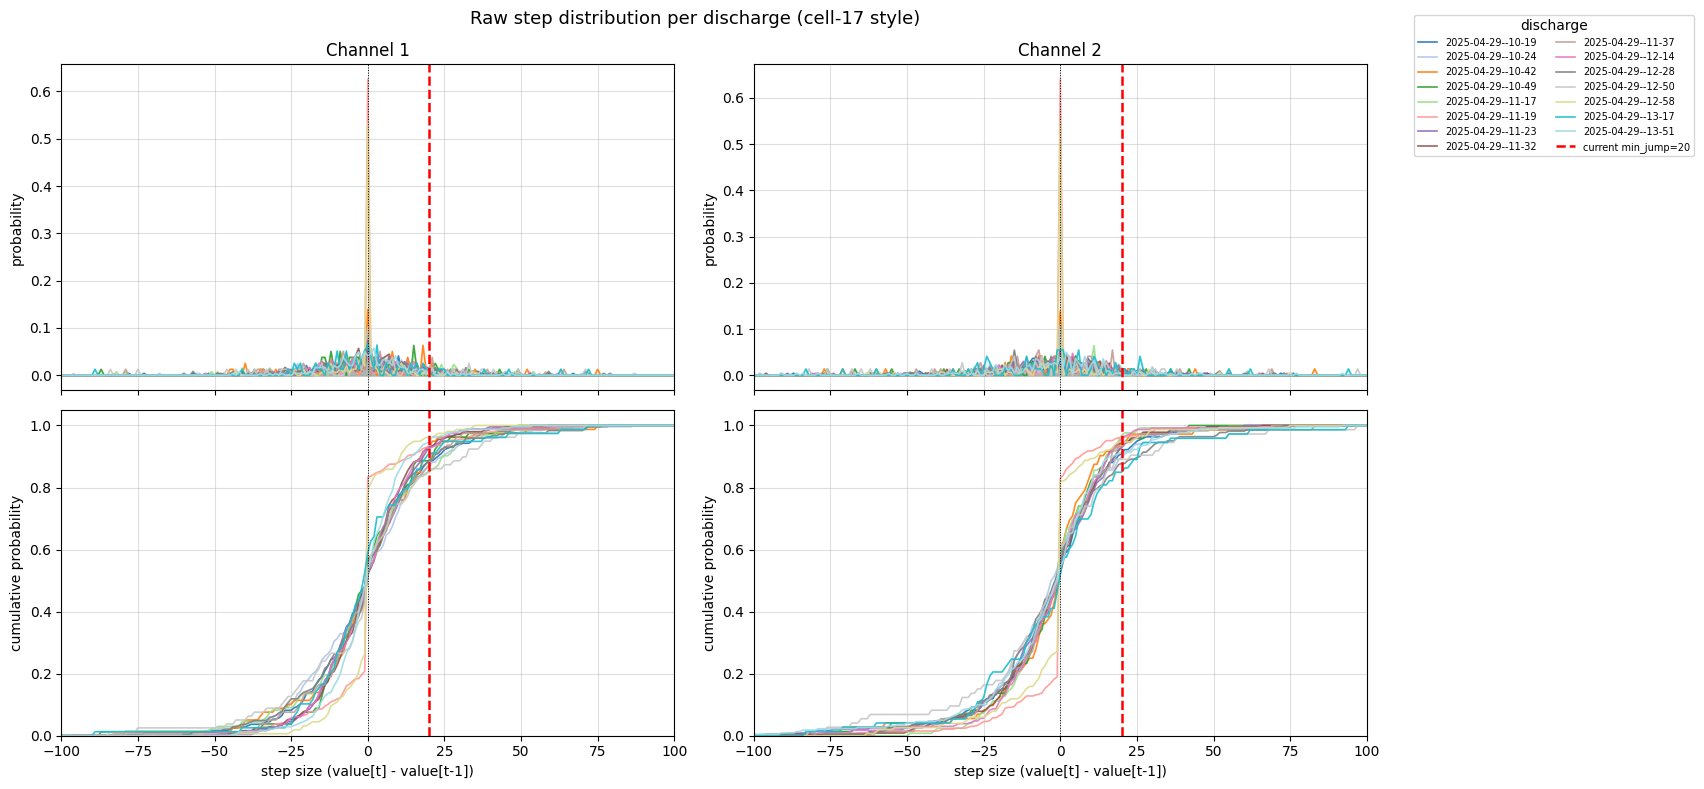

In [18]:
from pha_lib.config import InjectionDetectionConfig as _BaseConfig

CURRENT_MIN_JUMP = _BaseConfig().min_jump

folder_names = sorted(fluct_df["folder"].unique())
cmap = plt.get_cmap("tab20", max(len(folder_names), 1))

# Use raw 1-step bins only. No KDE, no Gaussian smoothing, no transformed data.
step_min = -100
step_max = 100
bin_edges = np.arange(step_min - 0.5, step_max + 1.5, 1.0)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, axes = plt.subplots(2, len(CHANNELS), figsize=(14, 8), sharex=True)
if len(CHANNELS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, ch in enumerate(CHANNELS):
    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    for idx, folder_name in enumerate(folder_names):
        subset = fluct_df[
            (fluct_df["folder"] == folder_name) & (fluct_df["channel_id"] == ch)
        ]["delta"].to_numpy(dtype=float)

        if subset.size == 0:
            continue

        # Raw histogram probabilities from the actual observed steps.
        counts, _ = np.histogram(subset, bins=bin_edges)
        probability = counts / counts.sum()
        cumulative = np.cumsum(probability)

        color = cmap(idx)

        # Top panel: raw probability histogram drawn as a finely sliced line/fill.
        ax_top.fill_between(bin_centers, probability, alpha=0.10, color=color)
        ax_top.plot(bin_centers, probability, color=color, lw=1.2, alpha=0.9, label=folder_name)

        # Bottom panel: cumulative probability from the same raw histogram.
        ax_bottom.plot(bin_centers, cumulative, color=color, lw=1.2, alpha=0.9, label=folder_name)

    ax_top.axvline(CURRENT_MIN_JUMP, color="red", linewidth=1.8, linestyle="--",
                   label=f"current min_jump={CURRENT_MIN_JUMP:.0f}")
    ax_top.axvline(0, color="black", linewidth=0.7, linestyle=":")
    ax_bottom.axvline(CURRENT_MIN_JUMP, color="red", linewidth=1.8, linestyle="--")
    ax_bottom.axvline(0, color="black", linewidth=0.7, linestyle=":")

    ax_top.set_title(f"Channel {ch}", fontsize=12)
    ax_top.set_ylabel("probability")
    ax_top.grid(alpha=0.4)
    ax_top.set_xlim(step_min, step_max)

    ax_bottom.set_xlabel("step size (value[t] - value[t-1])")
    ax_bottom.set_ylabel("cumulative probability")
    ax_bottom.set_ylim(0, 1.05)
    ax_bottom.grid(alpha=0.4)
    ax_bottom.set_xlim(step_min, step_max)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=7, ncol=2,
           bbox_to_anchor=(1.01, 0.98), loc="upper left", title="discharge")

fig.suptitle("Raw step distribution per discharge (cell-17 style)", fontsize=13)
plt.tight_layout()
plt.show()


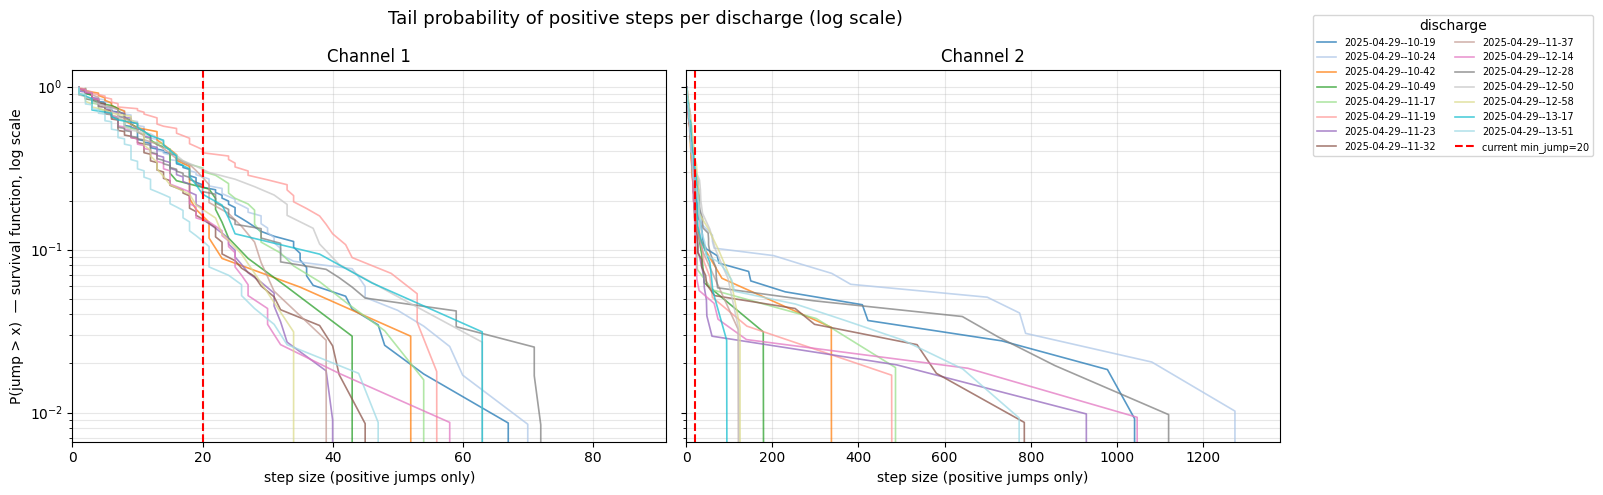

In [12]:
# Zoomed view: positive side only, log-scale y-axis to see the tail clearly.
# The tail is where real injections live and min_jump acts as a cutoff.
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(13, 5), sharey=True)
if len(CHANNELS) == 1:
    axes = [axes]

for ax, ch in zip(axes, CHANNELS):
    for idx, folder_name in enumerate(folder_names):
        subset = fluct_df[
            (fluct_df["folder"] == folder_name)
            & (fluct_df["channel_id"] == ch)
            & (fluct_df["delta"] > 0)
        ]["delta"].to_numpy(dtype=float)

        if subset.size == 0:
            continue

        # ECDF of positive jumps only.
        sorted_vals = np.sort(subset)
        # Survival function (1 - ECDF) on log scale highlights the right tail.
        ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        survival = 1.0 - ecdf

        ax.semilogy(sorted_vals, survival, color=cmap(idx), linewidth=1.2,
                    alpha=0.75, label=folder_name)

    ax.axvline(CURRENT_MIN_JUMP, color="red", linewidth=1.5, linestyle="--",
               label=f"current min_jump={CURRENT_MIN_JUMP:.0f}")

    ax.set_title(f"Channel {ch}", fontsize=12)
    ax.set_xlabel("step size (positive jumps only)")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlim(left=0)

axes[0].set_ylabel("P(jump > x)  — survival function, log scale")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=7, ncol=2,
           bbox_to_anchor=(1.01, 0.98), loc="upper left", title="discharge")

fig.suptitle("Tail probability of positive steps per discharge (log scale)", fontsize=13)
plt.tight_layout()
plt.show()
